# Day 16 — Scikit-learn & ML Workflow
### Train/Test Split · Cross-Validation · Pipelines · ColumnTransformer

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn import __version__ as sklearn_version

plt.style.use("dark_background")
sns.set_palette("husl")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")

print(f"Pandas:       {pd.__version__}")
print(f"NumPy:        {np.__version__}")
print(f"Scikit-learn: {sklearn_version}")
print(f"Dataset:      {df.shape}")
print("Ready! ✅")

Pandas:       2.3.3
NumPy:        2.4.3
Scikit-learn: 1.8.0
Dataset:      (891, 12)
Ready! ✅


## 2. The ML Workflow

In [ ]:
print("=" * 55)
print("         THE ML WORKFLOW")
print("=" * 55)
print(
    """
The standard ML workflow every Data Scientist follows:

1. COLLECT & UNDERSTAND DATA
   - Load data, explore shape, dtypes, missing values
   - EDA — distributions, correlations, outliers

2. PREPROCESS & FEATURE ENGINEERING
   - Handle missing values
   - Encode categorical variables
   - Scale numerical features
   - Create new features

3. SPLIT DATA
   - Train set (80%) — model learns from this
   - Test set (20%)  — evaluate on unseen data
   - NEVER touch test set until final evaluation!

4. TRAIN MODEL
   - Choose algorithm
   - Fit on training data only

5. EVALUATE MODEL
   - Cross-validation on train set
   - Final evaluation on test set
   - Metrics: accuracy, precision, recall, F1, AUC

6. TUNE & IMPROVE
   - Hyperparameter tuning
   - Feature selection
   - Try different algorithms

7. DEPLOY
   - Save model
   - Serve via API
   - Monitor in production

TODAY WE COVER: Steps 1-5 using Titanic dataset
"""
)

         THE ML WORKFLOW

The standard ML workflow every Data Scientist follows:

1. COLLECT & UNDERSTAND DATA
   - Load data, explore shape, dtypes, missing values
   - EDA — distributions, correlations, outliers

2. PREPROCESS & FEATURE ENGINEERING
   - Handle missing values
   - Encode categorical variables
   - Scale numerical features
   - Create new features

3. SPLIT DATA
   - Train set (80%) — model learns from this
   - Test set (20%)  — evaluate on unseen data
   - NEVER touch test set until final evaluation!

4. TRAIN MODEL
   - Choose algorithm
   - Fit on training data only

5. EVALUATE MODEL
   - Cross-validation on train set
   - Final evaluation on test set
   - Metrics: accuracy, precision, recall, F1, AUC

6. TUNE & IMPROVE
   - Hyperparameter tuning
   - Feature selection
   - Try different algorithms

7. DEPLOY
   - Save model
   - Serve via API
   - Monitor in production

TODAY WE COVER: Steps 1-5 using Titanic dataset



## 3. Data Preparation

In [ ]:
print("=" * 55)
print("         DATA PREPARATION")
print("=" * 55)

# Check missing values
print("\n--- Missing Values ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"Missing": missing, "Pct": missing_pct})
print(missing_df[missing_df["Missing"] > 0])

# Feature selection & cleaning
print("\n--- Feature Engineering ---")
df_clean = df.copy()

# Fill missing Age with median
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

# Fill missing Embarked with mode
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# Drop Cabin (too many missing), Name, Ticket (not useful)
df_clean = df_clean.drop(["Cabin", "Name", "Ticket", "PassengerId"], axis=1)

# Create new features
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1
df_clean["IsAlone"] = (df_clean["FamilySize"] == 1).astype(int)

print(f"Features created: FamilySize, IsAlone")
print(f"Shape after cleaning: {df_clean.shape}")
print(f"\nMissing values remaining: {df_clean.isnull().sum().sum()}")
print(f"\nFeatures: {list(df_clean.columns)}")
print(f"\nSample:")
print(df_clean.head(3))

         DATA PREPARATION

--- Missing Values ---
          Missing   Pct
Age           177  19.9
Cabin         687  77.1
Embarked        2   0.2

--- Feature Engineering ---
Features created: FamilySize, IsAlone
Shape after cleaning: (891, 10)

Missing values remaining: 0

Features: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']

Sample:
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked  FamilySize  \
0         0       3    male  22.0      1      0   7.2500        S           2   
1         1       1  female  38.0      1      0  71.2833        C           2   
2         1       3  female  26.0      0      0   7.9250        S           1   

   IsAlone  
0        0  
1        0  
2        1  


## 4. Train/Test Split

In [ ]:
print("=" * 55)
print("          TRAIN/TEST SPLIT")
print("=" * 55)

# Define features and target
X = df_clean.drop("Survived", axis=1)
y = df_clean["Survived"]

# Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nFull dataset:  {X.shape}")
print(f"Training set:  {X_train.shape} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set:      {X_test.shape} ({len(X_test)/len(X)*100:.0f}%)")

print(f"\nTarget distribution:")
print(f"  Train — Survived: {y_train.mean():.3f} ({y_train.sum()} passengers)")
print(f"  Test  — Survived: {y_test.mean():.3f} ({y_test.sum()} passengers)")
print(f"  ✅ Stratify kept same ratio in both sets!")

print(
    """
WHY STRATIFY?
  Without stratify: random split might put all survivors
  in train and none in test — biased evaluation!
  
  With stratify=y: survival ratio is same in both sets
  Train: 38.4% survived
  Test:  38.4% survived ← same!

WHY random_state=42?
  Makes the split reproducible — same split every time
  Anyone running your code gets identical results
"""
)

          TRAIN/TEST SPLIT

Full dataset:  (891, 9)
Training set:  (712, 9) (80%)
Test set:      (179, 9) (20%)

Target distribution:
  Train — Survived: 0.383 (273 passengers)
  Test  — Survived: 0.385 (69 passengers)
  ✅ Stratify kept same ratio in both sets!

WHY STRATIFY?
  Without stratify: random split might put all survivors
  in train and none in test — biased evaluation!

  With stratify=y: survival ratio is same in both sets
  Train: 38.4% survived
  Test:  38.4% survived ← same!

WHY random_state=42?
  Makes the split reproducible — same split every time
  Anyone running your code gets identical results



## 5. Scikit-learn Pipeline & ColumnTransformer

In [ ]:
print("=" * 55)
print("    PIPELINE & COLUMNTRANSFORMER")
print("=" * 55)

# Define feature types
numerical_features = ["Age", "Fare", "FamilySize", "SibSp", "Parch"]
categorical_features = ["Sex", "Embarked"]
passthrough_features = ["Pclass", "IsAlone"]

print(f"\nNumerical features:    {numerical_features}")
print(f"Categorical features:  {categorical_features}")
print(f"Passthrough features:  {passthrough_features}")

# Numerical pipeline — scale
numerical_pipeline = Pipeline([("scaler", StandardScaler())])

# Categorical pipeline — encode
categorical_pipeline = Pipeline(
    [("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]
)

# Combine with ColumnTransformer
preprocessor = ColumnTransformer(
    [
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features),
        ("pass", "passthrough", passthrough_features),
    ]
)

# Full pipeline: preprocessing + model
full_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42, max_iter=1000)),
    ]
)

print(f"\nPipeline steps:")
print(f"  1. preprocessor → scales numbers, encodes categories")
print(f"  2. classifier   → LogisticRegression")
print(f"\nWHY PIPELINES?")
print(f"  ✅ Prevents data leakage — fit only on train, transform both")
print(f"  ✅ One object to fit, predict, save")
print(f"  ✅ Easy to swap models or preprocessors")
print(f"  ✅ Works seamlessly with cross-validation")

    PIPELINE & COLUMNTRANSFORMER

Numerical features:    ['Age', 'Fare', 'FamilySize', 'SibSp', 'Parch']
Categorical features:  ['Sex', 'Embarked']
Passthrough features:  ['Pclass', 'IsAlone']

Pipeline steps:
  1. preprocessor → scales numbers, encodes categories
  2. classifier   → LogisticRegression

WHY PIPELINES?
  ✅ Prevents data leakage — fit only on train, transform both
  ✅ One object to fit, predict, save
  ✅ Easy to swap models or preprocessors
  ✅ Works seamlessly with cross-validation


## 6. Train & Cross-Validation

In [ ]:
print("=" * 55)
print("      TRAINING & CROSS-VALIDATION")
print("=" * 55)

# Cross-validation BEFORE final test
print("\n--- Cross-Validation on Training Set ---")
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=cv, scoring="accuracy")

print(f"\n5-Fold Cross-Validation Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f} ({score*100:.1f}%)")
print(f"\nMean CV Accuracy:  {cv_scores.mean():.4f} ({cv_scores.mean()*100:.1f}%)")
print(f"Std CV Accuracy:   {cv_scores.std():.4f} (±{cv_scores.std()*100:.1f}%)")

print(
    """
WHY CROSS-VALIDATION?
  Single train/test split can be lucky or unlucky.
  K-Fold CV trains K models on different splits
  and averages — much more reliable estimate!

  Fold 1: [TEST][TRAIN][TRAIN][TRAIN][TRAIN]
  Fold 2: [TRAIN][TEST][TRAIN][TRAIN][TRAIN]
  Fold 3: [TRAIN][TRAIN][TEST][TRAIN][TRAIN]
  ...and so on for 5 folds
"""
)

# Final training & test evaluation
print("--- Final Model Training & Test Evaluation ---")
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Set Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.1f}%)")
print(f"CV Mean Accuracy:   {cv_scores.mean():.4f} ({cv_scores.mean()*100:.1f}%)")
print(f"Difference:         {abs(test_accuracy - cv_scores.mean()):.4f}")

if abs(test_accuracy - cv_scores.mean()) < 0.05:
    print("✅ CV and test scores are close — model generalises well!")
else:
    print("⚠️ Large gap — possible overfitting!")

print(f"\n--- Classification Report ---")
print(
    classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"])
)

      TRAINING & CROSS-VALIDATION

--- Cross-Validation on Training Set ---

5-Fold Cross-Validation Scores:
  Fold 1: 0.7762 (77.6%)
  Fold 2: 0.7483 (74.8%)
  Fold 3: 0.7958 (79.6%)
  Fold 4: 0.8028 (80.3%)
  Fold 5: 0.8873 (88.7%)

Mean CV Accuracy:  0.8021 (80.2%)
Std CV Accuracy:   0.0466 (±4.7%)

WHY CROSS-VALIDATION?
  Single train/test split can be lucky or unlucky.
  K-Fold CV trains K models on different splits
  and averages — much more reliable estimate!

  Fold 1: [TEST][TRAIN][TRAIN][TRAIN][TRAIN]
  Fold 2: [TRAIN][TEST][TRAIN][TRAIN][TRAIN]
  Fold 3: [TRAIN][TRAIN][TEST][TRAIN][TRAIN]
  ...and so on for 5 folds

--- Final Model Training & Test Evaluation ---

Test Set Accuracy:  0.8045 (80.4%)
CV Mean Accuracy:   0.8021 (80.2%)
Difference:         0.0024
✅ CV and test scores are close — model generalises well!

--- Classification Report ---
                 precision    recall  f1-score   support

Did not survive       0.82      0.88      0.85       110
       Survived  

## 7. Visualising Model Performance

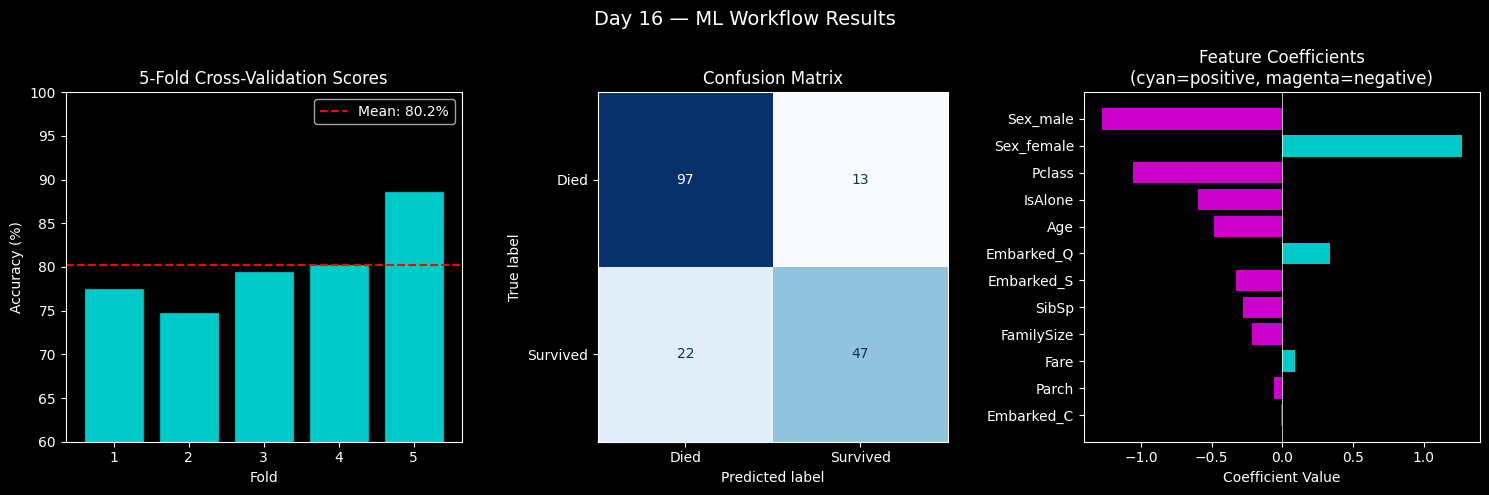

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Day 16 — ML Workflow Results", fontsize=14)

# 1 — CV scores
axes[0].bar(range(1, 6), cv_scores * 100, color="cyan", edgecolor="black", alpha=0.8)
axes[0].axhline(
    cv_scores.mean() * 100,
    color="red",
    linestyle="--",
    label=f"Mean: {cv_scores.mean()*100:.1f}%",
)
axes[0].set_title("5-Fold Cross-Validation Scores")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_xticks(range(1, 6))
axes[0].legend()
axes[0].set_ylim(60, 100)

# 2 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Died", "Survived"])
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix")

# 3 — Feature importance via coefficients
feature_names = (
    numerical_features
    + list(
        full_pipeline.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .get_feature_names_out()
    )
    + passthrough_features
)
coefficients = full_pipeline.named_steps["classifier"].coef_[0]
coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coefficients})
coef_df = coef_df.reindex(
    coef_df["Coefficient"].abs().sort_values(ascending=True).index
)

colors = ["magenta" if c < 0 else "cyan" for c in coef_df["Coefficient"]]
axes[2].barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, alpha=0.8)
axes[2].axvline(0, color="white", linewidth=0.5)
axes[2].set_title("Feature Coefficients\n(cyan=positive, magenta=negative)")
axes[2].set_xlabel("Coefficient Value")

plt.tight_layout()
plt.show()

## 8. Key Takeaways — Day 16 🎯

### The 7-Step ML Workflow
1. Collect & Understand Data
2. Preprocess & Feature Engineer
3. Split Data (train/test)
4. Train Model
5. Evaluate (cross-validation + test)
6. Tune & Improve
7. Deploy

### Data Preparation
- Age: 19.9% missing → filled with median
- Cabin: 77.1% missing → dropped entirely
- Created FamilySize = SibSp + Parch + 1
- Created IsAlone = 1 if FamilySize == 1

### Train/Test Split
- `train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)`
- 80% train (712 rows), 20% test (179 rows)
- **stratify=y** — keeps same survival ratio in both sets
- **random_state=42** — reproducible results

### Pipelines & ColumnTransformer
- Pipeline chains preprocessing + model into ONE object
- ColumnTransformer applies different transforms to different columns
- Numerical → StandardScaler
- Categorical → OneHotEncoder
- **Prevents data leakage** — fit only on train, transform both!

### Cross-Validation
- 5-Fold CV: splits train into 5 parts, trains 5 models
- Mean CV accuracy: **80.2%** ± 4.7%
- More reliable than single train/test split
- Test accuracy: **80.4%** — almost identical to CV mean ✅

### Model Results
- Logistic Regression accuracy: **80.4%**
- Better at predicting deaths (F1=0.85) than survivors (F1=0.73)
- Sex_female strongest positive coefficient (+1.2)
- Sex_male strongest negative coefficient (-1.2)
- Gender confirmed as strongest survival predictor

### Key sklearn Functions
- `train_test_split(X, y, test_size, random_state, stratify)`
- `KFold(n_splits=5, shuffle=True, random_state=42)`
- `cross_val_score(pipeline, X_train, y_train, cv, scoring)`
- `Pipeline([('name', transformer), ('name', model)])`
- `ColumnTransformer([('name', transformer, columns)])`
- `accuracy_score(y_test, y_pred)`
- `classification_report(y_test, y_pred)`